twitter16m dataset:

https://www.kaggle.com/datasets/kazanova/sentiment140

## Download Sentiment140 Dataset from Kaggle Hub

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2


In [18]:
import os

path = "/root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2"

file_list = os.listdir(path)
print("Files in the dataset:", file_list)

Files in the dataset: ['training.1600000.processed.noemoticon.csv']


In [19]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2"
csv_file = os.path.join(path, "training.1600000.processed.noemoticon.csv")

## Preprocessing

In [20]:
import numpy as np
import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv(csv_file, encoding='latin1', header=None)
print(df.head())

   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [22]:
print("Verisetinin boyutu:", df.shape)

Verisetinin boyutu: (1600000, 6)


In [23]:
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
print(df.head())

   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [24]:
df = df[['text', 'sentiment']]
df.head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [25]:
df.columns = ['tweets','sentiment']
df.head()

,tweets,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [26]:
df['sentiment'].value_counts()

,count
sentiment,
0,800000
4,800000


In [27]:
sent_map = {
    0: 'negative',
    4: 'positive'
}

In [28]:
df['word_counts'] = df['tweets'].apply(lambda x: len(str(x).split()))
df.head()

,tweets,sentiment,word_counts
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,19
1,is upset that he can't update his Facebook by ...,0,21
2,@Kenichan I dived many times for the ball. Man...,0,18
3,my whole body feels itchy and like its on fire,0,10
4,"@nationwideclass no, it's not behaving at all....",0,21


In [29]:
df['char_counts'] = df['tweets'].apply(lambda x: len(x))
df.head()

,tweets,sentiment,word_counts,char_counts
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,19,115
1,is upset that he can't update his Facebook by ...,0,21,111
2,@Kenichan I dived many times for the ball. Man...,0,18,89
3,my whole body feels itchy and like its on fire,0,10,47
4,"@nationwideclass no, it's not behaving at all....",0,21,111


In [30]:
def get_avg_word_len(x):
    words = x.split()
    word_len = 0
    for word in words:
        word_len = word_len + len(word)
    return word_len/len(words) # = len(x)/len(words)

In [31]:
df['avg_word_len'] = df['tweets'].apply(lambda x: get_avg_word_len(x))
df.head()

,tweets,sentiment,word_counts,char_counts,avg_word_len
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,19,115,5.052632
1,is upset that he can't update his Facebook by ...,0,21,111,4.285714
2,@Kenichan I dived many times for the ball. Man...,0,18,89,3.944444
3,my whole body feels itchy and like its on fire,0,10,47,3.700000
4,"@nationwideclass no, it's not behaving at all....",0,21,111,4.285714


In [32]:
print(STOP_WORDS)

{"'m", 'but', 'together', 'yourselves', 'thereby', 'n’t', 'enough', 'twelve', 'since', 'is', 'most', 'nothing', 'onto', 'you', 'further', '‘ll', 'ten', 'part', 'above', 'to', 'mostly', '’ve', 'sometime', 'up', 'elsewhere', 'everyone', 'six', 'top', 'own', 'becomes', 'seemed', 'whole', 'may', 'move', 'whither', 'much', 'do', 'hereupon', "'re", 'for', 'already', 'formerly', 'each', 'made', 'eleven', 'empty', '‘s', 'else', 'thereupon', 'ca', 'because', 'whereupon', 'will', 'n‘t', 'four', 'me', 'then', 'by', 'ours', 'while', 'again', 'whose', 'indeed', 'hundred', 'quite', 'five', 'afterwards', 'it', 'side', 'only', 'still', '‘m', 'herself', 'yet', 'became', 'somehow', 'until', "n't", 'well', 'both', 'our', 'must', 'full', 'whenever', 'third', 'everywhere', 'had', 'make', 'whatever', 'being', 're', 'a', 'hers', 'seeming', 'are', 'get', 'whence', 'call', 'this', 'nevertheless', 'am', 'an', 'various', 'all', 'thus', 'which', '’ll', 'nobody', 'eight', 'anyhow', 'last', 'go', 'always', 'namely'

In [33]:
print(len(STOP_WORDS))

326


In [34]:
x = 'this is text data'
x.split()

['this', 'is', 'text', 'data']

In [35]:
[t for t in x.split() if t in STOP_WORDS]

['this', 'is']

In [36]:
len([t for t in x.split() if t in STOP_WORDS])

2

In [37]:
df['tweets'].apply(lambda x: len([t for t in x.split() if t in STOP_WORDS]))

,tweets
0,4
1,9
2,7
3,5
4,10
...,...
1599995,4
1599996,1
1599997,5
1599998,3


In [38]:
df['stop_words_len'] = df['tweets'].apply(lambda x: len([t for t in x.split() if t in STOP_WORDS]))
df.head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,19,115,5.052632,4
1,is upset that he can't update his Facebook by ...,0,21,111,4.285714,9
2,@Kenichan I dived many times for the ball. Man...,0,18,89,3.944444,7
3,my whole body feels itchy and like its on fire,0,10,47,3.700000,5
4,"@nationwideclass no, it's not behaving at all....",0,21,111,4.285714,10


In [39]:
x = 'this is a #hashtag and this is @mention'
x.split()

['this', 'is', 'a', '#hashtag', 'and', 'this', 'is', '@mention']

In [40]:
[t for t in x.split() if t.startswith('#')]

['#hashtag']

In [41]:
len([t for t in x.split() if t.startswith('#')])

1

In [42]:
df['hashtags_count'] = df['tweets'].apply(lambda x: len([t for t in x.lower().split() if t.startswith('#')]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count
1007999,@onedayinmei yes..... that sweet sweet thought!,4,6,49,7.000000,1,0
1450898,@Mr_fritz oh how quickly you throw that out th...,4,21,112,4.333333,9,0
430552,might not be able to go to Cali. Maybe Canada...,0,21,96,3.571429,10,0
450467,I want a milkshake,0,4,19,3.750000,1,0
1234183,"@YoungQ Can't wait to see it, 3 days...3 shows...",4,15,83,4.533333,4,0


In [43]:
df['mentions_count'] = df['tweets'].apply(lambda x: len([t for t in x.lower().split() if t.startswith('@')]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count
715279,@iSUCK ineedthe toilet again.Im drinking wayy ...,0,9,62,5.888889,2,0,1
832291,"@thecraigmorris No, it's milk gravy with bits ...",4,21,134,5.380952,7,0,1
28873,is trying to enjoy twitter...,0,5,30,5.000000,2,0,0
1098447,"Zkouï¿½ka Twittu p?es transport,omlouvï¿½m se",4,5,46,8.200000,0,0,0
1599074,whoo! I actually had a post about JONAS that w...,4,15,83,4.333333,5,0,0


In [44]:
x = 'this is 1 and 2'
x.split()

['this', 'is', '1', 'and', '2']

In [45]:
x.split()[2].isdigit()

True

In [46]:
[t for t in x.split() if t.isdigit()]

['1', '2']

In [47]:
len([t for t in x.split() if t.isdigit()])

2

In [48]:
df['numerics_count'] = df['tweets'].apply(lambda x: len([t for t in x.split() if t.isdigit()]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count
1113895,Peperomia Rocks ! Pepito the Peperomiam ! The ...,4,14,77,4.500000,4,0,1,0
13282,has to work an overnight shift and has no idea...,0,15,71,3.666667,8,0,0,0
61379,back to the old stressful life! it's soooo sa...,0,9,51,4.666667,3,0,0,0
708939,"@JessMcFlyxxx no, its in the pictures folder o...",0,19,94,3.947368,11,0,1,0
1217424,"Nice looking day today...perhaps some high, th...",4,13,83,5.307692,3,0,0,0


In [49]:
df['numerics_count'].value_counts()

,count
numerics_count,
0,1484243
1,98734
2,14105
3,2298
4,485
5,94
6,30
8,5
7,4


In [50]:
x = 'I AM HAPPY'
y = 'i am happy'

In [51]:
[t for t in x.split() if t.isupper()]

['I', 'AM', 'HAPPY']

In [52]:
len([t for t in x.split() if t.isupper()])

3

In [53]:
df['upper_counts'] = df['tweets'].apply(lambda x: len([t for t in x.split() if t.isupper() and len(x)>3]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts
586714,@lilmzpartygurl I thought da hair was for me d...,0,11,59,4.363636,4,0,1,0,1
1135935,asking dad soon about warped,4,5,29,4.800000,1,0,0,0,0
342200,@FakerParis LOL Boy I have to say you have q...,0,15,85,4.533333,6,0,1,0,2
739212,I have a blister between my toes. It hurts to ...,0,11,51,3.636364,5,0,0,0,1
1099973,@ClareKenting Who's SuBo? Haha. Yea the judges...,4,17,95,4.588235,5,0,1,0,1


In [54]:
df['tweets'][785708]

'Hoping the day of packing/moving goes well for @Silversea23 and wishing I could be there to lend a hand. '

# Preprocessing and Cleaning

In [55]:
x = 'This is a Text'
x.lower()

'this is a text'

In [56]:
y = 45.0
str(y).lower()

'45.0'

In [57]:
df['tweets'] = df['tweets'].apply(lambda x: str(x).lower())
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts
1552742,@tommcfly i looooooooove uuuu,4,4,30,6.500000,1,0,1,0,0
464987,up studying for this nutrition exam cant wait...,0,16,80,4.000000,4,0,0,0,1
1039404,watching yes man and editing the other nine vi...,4,12,71,4.916667,4,0,0,0,1
1115563,@thefalsetruths zomg pics!!!!! and i want to r...,4,11,61,4.545455,4,0,1,0,2
1208880,@jordanlindvall hmmm. not raining in the west...,4,16,98,4.875000,4,0,1,0,1


In [58]:
contraction = {
  "ain't": "am not",
  "aren't": "are not",
  "bak": "back",
  "brng": "bring",
  "can't": "cannot",
  "can't've": "cannot have",
  "'cause": "because",
  "could've": "could have",
  "couldn't": "could not",
  "couldn't've": "could not have",
  "didn't": "did not",
  "didn't": "did not",
  "dis": "this",
  "don't": "do not",
  "hadn't": "had not",
  "hadn't've": "had not have",
  "hasn't": "has not",
  "haven't": "have not",
  "he'd": "he would",
  "he'd've": "he would have",
  "he'll": "he will",
  "he'll've": "he will have",
  "he's": "he is",
  "how'd": "how did",
  "how'd'y": "how do you",
  "how'll": "how will",
  "how's": "how is",
  "I'd": "I would",
  "I'd've": "I would have",
  "I'll": "I will",
  "I'll've": "I will have",
  "I'm": "I am",
  "I've": "I have",
  "i'm": "i am",
  "isn't": "is not",
  "it'd": "it had",
  "it'd've": "it would have",
  "it'll": "it will",
  "it'll've": "it will have",
  "it's": "it is",
  "let's": "let us",
  "ma'am": "madam",
  "mayn't": "may not",
  "might've": "might have",
  "mightn't": "might not",
  "mightn't've": "might not have",
  "must've": "must have",
  "mustn't": "must not",
  "mustn't've": "must not have",
  "needn't": "need not",
  " n ": "end",
  "needn't've": "need not have",
  "o'clock": "of the clock",
  "oughtn't": "ought not",
  "oughtn't've": "ought not have",
  "shan't": "shall not",
  "sha'n't": "shall not",
  "shan't've": "shall not have",
  "she'd": "she would",
  "she'd've": "she would have",
  "she'll": "she will",
  "she'll've": "she will have",
  "she's": "she is",
  "should've": "should have",
  "shouldn't": "should not",
  "shouldn't've": "should not have",
  "so've": "so have",
  "so's": "so is",
  "that'd": "that would",
  "that'd've": "that would have",
  "that's": "that is",
  "there'd": "there had",
  "there'd've": "there would have",
  "there's": "there is",
  "they'd": "they would",
  "they'd've": "they would have",
  "they'll": "they will",
  "they'll've": "they will have",
  "they're": "they are",
  "they've": "they have",
  "to've": "to have",
  " u ": "you",
  " ur ": "your",
  "wasn't": "was not",
  "we'd": "we had",
  "we'd've": "we would have",
  "we'll": "we will",
  "we'll've": "we will have",
  "we're": "we are",
  "we've": "we have",
  "weren't": "were not",
  "what'll": "what will",
  "what'll've": "what will have",
  "what're": "what are",
  "what's": "what is",
  "what've": "what have",
  "when's": "when is",
  "when've": "when have",
  "where'd": "where did",
  "where's": "where is",
  "where've": "where have",
  "who'll": "who will",
  "who'll've": "who will have",
  "who's": "who is",
  "who've": "who have",
  "why's": "why is",
  "why've": "why have",
  "will've": "will have",
  "won't": "will not",
  "won't've": "will not have",
  "would've": "would have",
  "wouldn't": "would not",
  "wouldn't've": "would not have",
  "y'all": "you all",
  "y'alls": "you alls",
  "y'all'd": "you all would",
  "y'all'd've": "you all would have",
  "y'all're": "you all are",
  "y'all've": "you all have",
  "you'd": "you had",
  "you'd've": "you would have",
  "you'll": "you you will",
  "you'll've": "you you will have",
  "you're": "you are",
  "you've": "you have"
}

In [59]:
x = "i don't know what you want, can't, he'll, i'd"       # i am do not he will
def con_to_exp(x):
    if type(x) is str:
        for key, value in contraction.items():
            x = x.replace(key, value)
        return x
    return x

In [60]:
con_to_exp(x)

"i do not know what you want, cannot, he will, i'd"

In [61]:
%%timeit
df['tweets'] = df['tweets'].apply(lambda x: con_to_exp(x))

34.9 s ± 633 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [62]:
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts
498102,i just want to go home..,0,6,25,3.166667,3,0,0,0,1
41521,@pl that happened to jump recently and we lost...,0,23,127,4.521739,9,0,1,0,1
363847,"btw, i am angry cuz someone took my chilaquile...",0,14,69,3.928571,4,0,0,0,1
446226,@christom congrats!!! i am sorry i missed it. ...,0,12,77,5.416667,2,1,1,0,1
1341621,big brother 10 tonight,4,4,23,4.750000,0,0,0,1,0


## count and remove email

In [63]:
import re

In [64]:
df['tweets']

,tweets
0,"@switchfoot http://twitpic.com/2y1zl - awww, t..."
1,is upset that he cannot update his facebook by...
2,@kenichan i dived many times for the ball. man...
3,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it is not behaving at all..."
...,...
1599995,just woke up. having no school is the best fee...
1599996,thewdb.com - very cool to hear old walt interv...
1599997,are you ready for your mojo makeover? ask me f...
1599998,happy 38th birthday to my boo of alll time!!! ...


In [65]:
df['tweets'][df['tweets'].str.contains('gmail.com')].head()

,tweets
7917,who stole elledell@gmail.com?
8496,@alexistehpom really? did you send out all th...
156143,@fuzeb sounds like you are punking us kidding...
195726,need help to pay my rent chipin widget on the...
204098,using the mobile internet (i.e. m.gmail.com) i...


In [66]:
df['tweets'][7917]

'who stole elledell@gmail.com?  '

In [67]:
df['tweets'][df['tweets'].str.contains('hotmail.com')].head()

,tweets
10290,@laureystack awh...that is kinda sad lol add ...
123047,than 10 years of his 27 years of life thinks h...
288421,esta foto otra vez no tengo mas fotos ce...
346463,@willysandi tatha_7474@hotmail.com tapi msn gw...
364780,"@punchlion sarah, blondsugababe@hotmail.com, n..."


In [68]:
df['tweets'][10290]

'@laureystack awh...that is kinda sad  lol add me?? hello.kitty.65@hotmail.com'

In [69]:
x = '@securerecs arghh me please  markbradbury_16@hotmail.com'
re.findall(r'[a-z0-9+.-_]+@[a-z0-9+.-_]+\.[a-z0-9+.-_]+', x)

['markbradbury_16@hotmail.com']

In [70]:
df['emails'] = df['tweets'].apply(lambda x: re.findall(r'[a-z0-9+.-_]+@[a-z0-9+.-_]+\.[a-z0-9+.-_]+', x))

In [71]:
df['emails_count'] = df['emails'].apply(lambda x: len(x))

In [72]:
(df['emails_count']>0).value_counts()

,count
emails_count,
False,1599403
True,597


In [73]:
df[df['emails_count']>0].head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count
4054,i want a new laptop. hp tx2000 is the bomb. :...,0,20,103,4.150000,6,0,0,0,4,[gabbehhramos@yahoo.com],1
7917,who stole elledell@gmail.com?,0,3,31,9.000000,1,0,0,0,0,[elledell@gmail.com?],1
8496,@alexistehpom really? did you send out all th...,0,20,130,5.500000,11,0,1,0,0,[missataari@gmail.com],1
10290,@laureystack awh...that is kinda sad lol add ...,0,8,76,8.500000,0,0,1,0,0,[hello.kitty.65@hotmail.com],1
16413,"@jilliancyork got 2 bottom of it, human error...",0,21,137,5.428571,7,0,1,1,0,[press@linkedin.com],1


In [74]:
#remove emails
re.sub(r'[a-z0-9+.-_]+@[a-z0-9+.-_]+\.[a-z0-9+.-_]+', '', x).strip()

'@securerecs arghh me please'

In [75]:
df['tweets'] = df['tweets'].apply(lambda x: re.sub(r'[a-z0-9+.-_]+@[a-z0-9+.-_]+\.[a-z0-9+.-_]+', '', x))

In [76]:
df[df['emails_count']>0].head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count
4054,i want a new laptop. hp tx2000 is the bomb. :...,0,20,103,4.150000,6,0,0,0,4,[gabbehhramos@yahoo.com],1
7917,who stole,0,3,31,9.000000,1,0,0,0,0,[elledell@gmail.com?],1
8496,@alexistehpom really? did you send out all th...,0,20,130,5.500000,11,0,1,0,0,[missataari@gmail.com],1
10290,@laureystack awh...that is kinda sad lol add ...,0,8,76,8.500000,0,0,1,0,0,[hello.kitty.65@hotmail.com],1
16413,"@jilliancyork got 2 bottom of it, human error...",0,21,137,5.428571,7,0,1,1,0,[press@linkedin.com],1


In [77]:
df['tweets'][4054]

'i want a new laptop.  hp tx2000 is the bomb. :| who knows how much it is? im me: '

## Count and Remove URLs

In [78]:
x = 'hi, thanks to watching to it. for more visit https://youtube.com/NLP-Preprocessing'
re.findall(r"(http|https|ftp|ssh)://([\w_-]+(?:\.[\w_-]+)+)([\w.,@?^=%&:/~+#-]*)?", x)

[('https', 'youtube.com', '/NLP-Preprocessing')]

In [79]:
df['url_flags'] = df['tweets'].apply(lambda x: len(re.findall(r"(http|https|ftp|ssh)://([\w_-]+(?:\.[\w_-]+)+)([\w.,@?^=%&:/~+#-]*)?", x)))

In [80]:
df[df['url_flags']>0].head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
0,"@switchfoot http://twitpic.com/2y1zl - awww, t...",0,19,115,5.052632,4,0,1,0,1,[],0,1
37,@missxu sorry! bed time came here (gmt+1) ht...,0,8,61,6.500000,1,0,1,0,1,[],0,1
50,broadband plan 'a massive broken promise' http...,0,15,129,7.600000,4,0,0,0,0,[],0,1
74,why will not you show my location?! http://t...,0,7,59,7.285714,3,0,0,0,0,[],0,1
95,strider is a sick little puppy http://apps.fa...,0,7,85,11.142857,2,0,0,0,0,[],0,1


Remove

In [81]:
x = 'hi, thanks to watching to it. for more visit https://youtube.com/NLP-Preprocessing'
re.sub(r"(http|https|ftp|ssh)://([\w_-]+(?:\.[\w_-]+)+)([\w.,@?^=%&:/~+#-]*)?", '' , x).strip()

'hi, thanks to watching to it. for more visit'

In [82]:
df['tweets'] = df['tweets'].apply(lambda x: re.sub(r"(http|https|ftp|ssh)://([\w_-]+(?:\.[\w_-]+)+)([\w.,@?^=%&:/~+#-]*)?", '' , x))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
1368429,@geeeasy lol but did i put smile in face??,4,9,43,3.777778,4,0,1,0,1,[],0,0
696822,@kaiphoenix i accepted your party request but...,0,10,64,5.300000,3,0,1,0,1,[],0,0
1116312,check out these social networking sites that p...,4,13,85,5.538462,6,0,0,0,0,[],0,1
1029179,just hanging at home with the family,4,7,37,4.285714,3,0,0,0,0,[],0,0
527740,@omfgshauniesays aw thats not fair i dont un...,0,18,122,5.722222,6,0,1,0,0,[],0,0


## Remove RT (ReTweet)

In [83]:
df[df['tweets'].str.contains('rt')].head(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
16,hollis' death scene will hurt me severely to w...,0,18,93,4.166667,7,0,0,0,0,[],0,0
41,he is the reason for the teardrops on my guita...,0,21,99,3.714286,15,0,0,0,0,[],0,0
43,@jonathanrknight awww i soo wish i was there t...,0,19,101,4.315789,7,0,1,0,3,[],0,0
44,falling asleep. just heard about that tracy gi...,0,19,110,4.789474,5,0,0,0,0,[],0,0
68,@katortiz not forever... see you soon!,0,6,39,5.500000,1,0,1,0,0,[],0,0


In [84]:
len(df[df['tweets'].str.contains('rt')])

161194

In [85]:
x = 'rt @username: hello my name is xrtrtrt'
re.sub(r'\brt\b', '', x).strip()

'@username: hello my name is xrtrtrt'

In [86]:
df['tweets'] = df['tweets'].apply(lambda x: re.sub(r'\brt\b', '', x).strip())

## Special Characters Removal or Punctuation Removal

In [87]:
df.head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
0,"@switchfoot - awww, that is a bummer. you sh...",0,19,115,5.052632,4,0,1,0,1,[],0,1
1,is upset that he cannot update his facebook by...,0,21,111,4.285714,9,0,0,0,0,[],0,0
2,@kenichan i dived many times for the ball. man...,0,18,89,3.944444,7,0,1,0,1,[],0,0
3,my whole body feels itchy and like its on fire,0,10,47,3.700000,5,0,0,0,0,[],0,0
4,"@nationwideclass no, it is not behaving at all...",0,21,111,4.285714,10,0,1,0,1,[],0,0


In [88]:
x = '@zvespano hey zhirlyn congrats onyourbaby girl...'
re.sub(r'[^\w\s]', '', x)

'zvespano hey zhirlyn congrats onyourbaby girl'

In [89]:
df['tweets'] = df['tweets'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
304808,i just dropped a butter knife on my toe,0,9,40,3.444444,5,0,0,0,0,[],0,0
793486,i wish i have a cool old name like emily eliza...,0,24,124,4.166667,5,0,0,0,4,[],0,0
60484,booring do not know what to wear on the confir...,0,9,54,5.000000,4,0,0,0,0,[],0,0
165354,alwaysmuah hey ruthie girlyousend me all these...,0,20,118,4.900000,6,0,1,0,0,[],0,0
724250,linkin park it is not what it used to be it i...,0,13,61,3.692308,8,0,0,0,0,[],0,0


## Remove Multiple Spaces

In [90]:
x = "hi,    is       there    any       pharmacy?     "
x.split()

['hi,', 'is', 'there', 'any', 'pharmacy?']

In [91]:
' '.join(x.split())

'hi, is there any pharmacy?'

In [92]:
df['tweets'] = df['tweets'].apply(lambda x: ' '.join(x.split()))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
794792,this boy quotgeoffquot was our garden helpgod ...,0,25,142,4.680000,11,0,0,0,0,[],0,0
149547,nessak i am on the last one without p wings an...,0,19,97,4.105263,10,0,1,0,1,[],0,0
1156852,morning all how are we all this morning,4,8,41,4.125000,6,0,0,0,0,[],0,0
1061430,buffywoo oh rock on glad you like em,4,8,42,4.250000,1,0,1,0,0,[],0,0
320522,me fran and chloe on the last ever day of school,0,13,76,4.846154,6,0,0,0,0,[],0,1


## Remove HTML Tags

first way (Not recommended)

In [93]:
x = '<html><h1> thanks for watching it </h1></html>'
x.replace('<html><h1>', '').replace('</h1></html>', '')

' thanks for watching it '

second way (recommended)

In [94]:
#!pip install bs4
from bs4 import BeautifulSoup

In [95]:
BeautifulSoup(x, 'lxml').get_text().strip()

'thanks for watching it'

In [96]:
%%time
df['tweets'] = df['tweets'].apply(lambda x: BeautifulSoup(x, 'lxml').get_text().strip())

CPU times: user 4min 35s, sys: 3.84 s, total: 4min 39s
Wall time: 4min 37s


In [97]:
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
903911,mmwine lucky you i face south so i can hear th...,4,18,93,4.166667,7,0,1,0,2,[],0,0
1091508,sweetkittie excellent heres to another 10000,4,6,49,7.166667,2,0,1,0,0,[],0,0
633411,paulaabdul rich tweeted me y will not u i thty...,0,12,60,4.000000,1,0,1,0,2,[],0,0
350694,dementia i do not have simple pamps only,0,7,44,5.285714,2,0,1,0,0,[],0,0
1507061,mackduncan hi mack,4,3,21,6.000000,0,0,1,0,0,[],0,0


## Remove Accented Characters

In [98]:
import unicodedata

In [99]:
x = 'Àccêntêd Chârâctérs'
def remove_accented_chars(x):
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    return x

In [100]:
remove_accented_chars(x)

'Accented Characters'

In [101]:
df['tweets'].apply(lambda x: remove_accented_chars(x)).head()

,tweets
0,switchfoot awww that is a bummer you shoulda g...
1,is upset that he cannot update his facebook by...
2,kenichan i dived many times for the ball manag...
3,my whole body feels itchy and like its on fire
4,nationwideclass no it is not behaving at all i...


# SpaCy and NLP

## Remove Stopwords

In [102]:
import spacy

In [103]:
x = "this is stopwords removal code is a the an how what"
' '.join([t for t in x.split() if t not in STOP_WORDS])

'stopwords removal code'

In [104]:
df['tweets'] = df['tweets'].apply(lambda x: ' '.join([t for t in x.split() if t not in STOP_WORDS]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
1225477,omg wow queenofshops packed huge box stock 60 ...,4,22,131,4.954545,5,0,2,1,0,[],0,0
695556,paponyc lukcy raindrops r falling head city,0,12,66,4.500000,4,0,1,0,1,[],0,0
418536,hospitalmy grandas good,0,8,50,5.250000,4,0,0,0,0,[],0,0
1532665,interview mead thursday stoked designing,4,15,79,4.266667,8,0,0,0,1,[],0,0
1238445,cherylrushing oh yeahwell,4,7,50,6.142857,3,0,1,0,1,[],0,0


## Convert into Base or Root Form of Word

In [105]:
nlp = spacy.load('en_core_web_sm')

In [106]:
x = 'this is chocolates. what is times? this is balls'
def make_to_base(x):
    x_list = []
    doc = nlp(x)
    for token in doc:
        lemma = str(token.lemma_)
        if lemma == '-PRON-' or lemma == 'be':
            lemma = token.text
        x_list.append(lemma)
    print(" ".join(x_list))

In [107]:
make_to_base(x)

this is chocolate . what is time ? this is ball


In [108]:
#df['tweets'].apply(lambda x: make_to_base(x))

## Common Occuring words Removal

In [109]:
x = 'this is this okay bye'
df['tweets'].head()

,tweets
0,switchfoot awww bummer shoulda got david carr ...
1,upset update facebook texting cry result schoo...
2,kenichan dived times ball managed save 50 rest...
3,body feels itchy like fire
4,nationwideclass behaving mad


In [110]:
text = ' '.join(df['tweets'])
text[:500]

'switchfoot awww bummer shoulda got david carr day d upset update facebook texting cry result school today blah kenichan dived times ball managed save 50 rest bounds body feels itchy like fire nationwideclass behaving mad kwesidei crew need hug loltrish hey long time yes rains bit bit lol fine thanks tatiana_k nope twittera que muera spring break plain city snowing repierced ears caregiving bear watch thought ua loss embarrassing octolinz16 counts idk talk anymore smarrison gun zac snyders douche'

In [111]:
len(text) # number of chars

71750843

In [112]:
len(text.split()) # number of words

10772641

In [113]:
freq_common = pd.Series(text.split()).value_counts()
freq_common.head(10)

,count
good,89257
day,82034
like,76865
today,64439
going,63825
work,62648
love,61963
got,60004
time,55888
lol,54704


In [114]:
f20 = freq_common[:20]
f20

,count
good,89257
day,82034
like,76865
today,64439
going,63825
work,62648
love,61963
got,60004
time,55888
lol,54704


In [115]:
df['tweets'] = df['tweets'].apply(lambda x: ' '.join([t for t in x.split() if t not in f20]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
103530,boyfriend month mom wont let come oversadness ...,0,19,101,4.315789,10,0,0,0,0,[],0,0
1259708,lonelydays17 haha alll,4,8,47,4.875000,4,0,1,0,0,[],0,0
517743,omg looked sum spam followers gonna stay 5 2 4...,0,30,129,3.300000,14,0,0,3,0,[],0,0
1089098,triciagoyer lovely film,4,5,35,6.000000,1,0,1,0,0,[],0,0
620500,flight delayed freezing,0,4,29,6.250000,1,0,0,0,0,[],0,0


## Rare Occuring words Removal

In [116]:
rare20 = freq_common.tail(20)
rare20

,count
laurawashere09,1
cardiogram,1
cndd,1
huhdid,1
archit,1
happining,1
wallydragon,1
fionamacgyver,1
nairne,1
markeybee,1


In [117]:
df['tweets'] = df['tweets'].apply(lambda x: ' '.join([t for t in x.split() if t not in rare20]))
df.sample(5)

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
788750,tontokaruyouwould lying said forgot ill lie do...,0,22,99,3.500000,8,0,1,0,4,[],0,0
1574764,btw turned incredible hulk feel little solidar...,4,23,138,5.000000,8,1,0,0,3,[],0,0
1557137,finished book vacation farlostampfoundvery act...,4,16,112,6.000000,5,0,0,0,0,[],0,0
1300211,bluewaves1 sit bank lost check book close,4,24,117,3.833333,15,0,1,0,0,[],0,0
1144484,okay laughs sorry twitter song,4,11,67,5.090909,3,0,0,0,1,[],0,0


## Word cloud Vizualization

In [118]:
#!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

In [119]:
text[:500]

'switchfoot awww bummer shoulda got david carr day d upset update facebook texting cry result school today blah kenichan dived times ball managed save 50 rest bounds body feels itchy like fire nationwideclass behaving mad kwesidei crew need hug loltrish hey long time yes rains bit bit lol fine thanks tatiana_k nope twittera que muera spring break plain city snowing repierced ears caregiving bear watch thought ua loss embarrassing octolinz16 counts idk talk anymore smarrison gun zac snyders douche'

In [120]:
text = ' '.join(df['tweets'])

In [121]:
len(text)

66461828

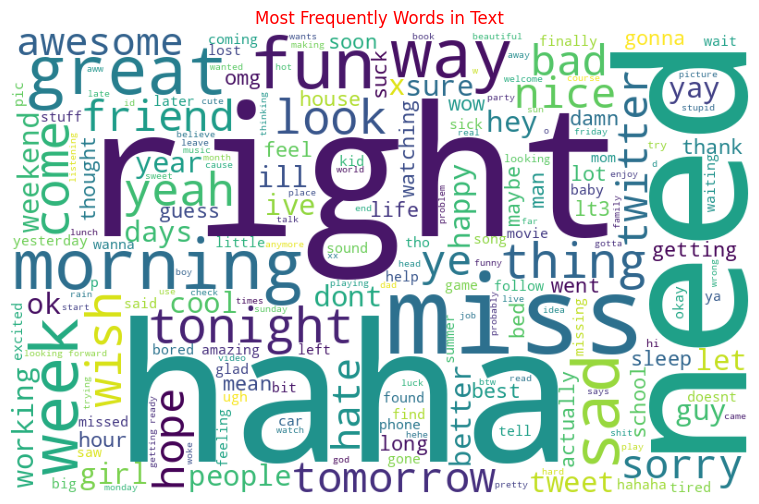

In [122]:
wc = WordCloud(width=800, height=500, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.title('Most Frequently Words in Text', color='red')
plt.axis('off')
plt.show()

## TextBlob for:
- Spelling Correction
- Tokenization
- Detecting Nouns
- Language Translation and Detection

### Spelling correction

In [123]:
!pip install textblob
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [124]:
from textblob import TextBlob
from textblob.exceptions import TranslatorError

In [125]:
x = 'thankks forr reading it'

In [126]:
x = TextBlob(x).correct()
x

TextBlob("thanks for reading it")

### Tokenization

In [127]:
x = 'thanks#watching this video. please like it'
TextBlob(x).words

WordList(['thanks', 'watching', 'this', 'video', 'please', 'like', 'it'])

In [128]:
doc = nlp(x)
for token in doc:
    print(token)

thanks#watching
this
video
.
please
like
it


### Lemmatization

In [129]:
from textblob import Word

In [130]:
x = "runs run running runner ran"
for token in x.split():
    print(Word(token).lemmatize())

run
run
running
runner
ran


In [131]:
doc = nlp(x)
for token in doc:
    print(token.lemma_)

run
run
run
runner
run


### Detecting Entities using NER

In [132]:
from spacy import displacy

In [133]:
x = "New York City on Tuesday declared a public health emergency and ordered mandatory measles vaccinations amid on outbreak, becoming the latest national flash point over refusals to inoculate against dangeraus diseases. At least 285 people have contracted measles in the city since September, mostly in Brooklyn's Williamsburg neighborhood. The order covers four Zip codes there, Mayor Bill de Blasio (D) said Tuesday. The mandate orders all unvaccinated people in the area, including a concentration of Orthod ox Jews, to receive incluations, including for children as young as 6 months old. Anyone who resists could be fined up to $1,000."
doc = nlp(x)
for ent in doc.ents:
    print(ent.text + ' - ' + ent.label_ + ' - ' + str(spacy.explain(ent.label_)))

New York City - GPE - Countries, cities, states
Tuesday - DATE - Absolute or relative dates or periods
At least 285 - CARDINAL - Numerals that do not fall under another type
September - DATE - Absolute or relative dates or periods
Brooklyn - GPE - Countries, cities, states
Williamsburg - GPE - Countries, cities, states
four - CARDINAL - Numerals that do not fall under another type
Zip - PERSON - People, including fictional
Bill de Blasio - PERSON - People, including fictional
Tuesday - DATE - Absolute or relative dates or periods
Orthod - ORG - Companies, agencies, institutions, etc.
Jews - NORP - Nationalities or religious or political groups
as young as 6 months old - DATE - Absolute or relative dates or periods
up to $1,000 - MONEY - Monetary values, including unit


In [134]:
displacy.render(doc, style="ent")

### POS (Part of Speech)

In [219]:
x = 'Breaking News: Donald Trump, the president of the USA is looking to sign a deal to mine to moon'
doc = nlp(x)

In [220]:
for token in doc:
  print(token.text,'-', token.pos_)

Breaking - VERB
News - PROPN
: - PUNCT
Donald - PROPN
Trump - PROPN
, - PUNCT
the - DET
president - NOUN
of - ADP
the - DET
USA - PROPN
is - AUX
looking - VERB
to - PART
sign - VERB
a - DET
deal - NOUN
to - ADP
mine - NOUN
to - ADP
moon - NOUN


In [215]:
displacy.render(doc, style="dep")

### Noun Detection

In [138]:
doc = nlp(x)
for noun in doc.noun_chunks:
    print(noun)

Breaking News
Donald Trump
the president
the USA
a deal
mine
moon


### Translation and Language Detection
>   Language Code: https://www.loc.gov/standards/iso639-2/php/code_list.php

In [139]:
!pip install translate
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=3a4efbe6ec965f478a6ac83349590dd2aae69790b571df1d7d3bfa4f520eced8
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


Detecting

In [140]:
from langdetect import detect

In [141]:
x = 'Breaking News: Donald Trump, the president of the USA is looking to sign a deal to mine to moon'
x

'Breaking News: Donald Trump, the president of the USA is looking to sign a deal to mine to moon'

In [142]:
detect(x)

'en'

Translation

In [143]:
from translate import Translator

In [144]:
translator = Translator(to_lang="de")
translator.translate(x)

'Eilmeldung: Donald Trump, der Präsident der USA, will einen Vertrag über die Mine to Moon unterzeichnen'

### Using Inbuilt `Sentiment Classifier`

In [145]:
from textblob.sentiments import NaiveBayesAnalyzer

In [146]:
x = 'we all stands together. we are gonna win this fight'
TextBlob(x, analyzer= NaiveBayesAnalyzer()).sentiment

Sentiment(classification='pos', p_pos=0.9180581552428241, p_neg=0.0819418447571765)

# ADVANCED TEXT PROCESSING

### N-Grams

In [147]:
x = 'we all stands together. we are gonna win this fight'
tb = TextBlob(x)
tb.ngrams(3)

[WordList(['we', 'all', 'stands']),
 WordList(['all', 'stands', 'together']),
 WordList(['stands', 'together', 'we']),
 WordList(['together', 'we', 'are']),
 WordList(['we', 'are', 'gon']),
 WordList(['are', 'gon', 'na']),
 WordList(['gon', 'na', 'win']),
 WordList(['na', 'win', 'this']),
 WordList(['win', 'this', 'fight'])]

### Bag of Words BoW

In [148]:
from sklearn.feature_extraction.text import CountVectorizer

In [149]:
x = ["this is first sentence", "this is second", "this is last"]

In [150]:
cv = CountVectorizer(ngram_range=(1,1))
text_counts = cv.fit_transform(x)
text_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (3, 6)>

In [151]:
text_counts.toarray()

array([[1, 1, 0, 0, 1, 1],
       [0, 1, 0, 1, 0, 1],
       [0, 1, 1, 0, 0, 1]])

In [152]:
bow = pd.DataFrame(text_counts.toarray(), columns=cv.get_feature_names_out())
bow

,first,is,last,second,sentence,this
0,1,1,0,0,1,1
1,0,1,0,1,0,1
2,0,1,1,0,0,1


### Term Frequency

In [153]:
x

['this is first sentence', 'this is second', 'this is last']

In [154]:
bow

,first,is,last,second,sentence,this
0,1,1,0,0,1,1
1,0,1,0,1,0,1
2,0,1,1,0,0,1


In [155]:
bow.shape

(3, 6)

In [156]:
tf = bow/bow.shape[1]
for index, row in enumerate(bow.iterrows()):
    for col in row[1].index:
        bow.loc[index,col] = bow.loc[index,col]/sum(row[1].values)

In [157]:
bow

,first,is,last,second,sentence,this
0,0.25,0.250000,0.000000,0.000000,0.25,0.250000
1,0.00,0.333333,0.000000,0.333333,0.00,0.333333
2,0.00,0.333333,0.333333,0.000000,0.00,0.333333


### Inverse Document Frequency `IDF`
idf = log((1+N)/(n+1)) + used in sklearn when smooth_idf=True
where, `N` is the total number of rows and `n` is the number of rows in which the word was present

In [158]:
import numpy as np

In [159]:
x_df = pd.DataFrame(x, columns=['words'])
x_df

,words
0,this is first sentence
1,this is second
2,this is last


In [160]:
bow

,first,is,last,second,sentence,this
0,0.25,0.250000,0.000000,0.000000,0.25,0.250000
1,0.00,0.333333,0.000000,0.333333,0.00,0.333333
2,0.00,0.333333,0.333333,0.000000,0.00,0.333333


In [161]:
N = bow.shape[0]
N

3

In [162]:
bb = bow.astype('bool')
bb

,first,is,last,second,sentence,this
0,True,True,False,False,True,True
1,False,True,False,True,False,True
2,False,True,True,False,False,True


In [163]:
bb[['this','is','first']].sum()

,0
this,3
is,3
first,1


In [164]:
cols = bb.columns
cols

Index(['first', 'is', 'last', 'second', 'sentence', 'this'], dtype='object')

In [165]:
nz = []
for col in cols:
    nz.append(bb[col].sum())

nz

[1, 3, 1, 1, 1, 3]

In [166]:
idf = []
for index, col in enumerate(cols):
    idf.append(np.log((N+1)/(nz[index]+1))+1)

idf

[1.6931471805599454,
 1.0,
 1.6931471805599454,
 1.6931471805599454,
 1.6931471805599454,
 1.0]

In [167]:
bow

,first,is,last,second,sentence,this
0,0.25,0.250000,0.000000,0.000000,0.25,0.250000
1,0.00,0.333333,0.000000,0.333333,0.00,0.333333
2,0.00,0.333333,0.333333,0.000000,0.00,0.333333


### TFIDF

In [168]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [169]:
tfidf = TfidfVectorizer()
x_tfidf = tfidf.fit_transform(x_df['words'])

In [170]:
x_tfidf.toarray()

array([[0.6088451 , 0.35959372, 0.        , 0.        , 0.6088451 ,
        0.35959372],
       [0.        , 0.45329466, 0.        , 0.76749457, 0.        ,
        0.45329466],
       [0.        , 0.45329466, 0.76749457, 0.        , 0.        ,
        0.45329466]])

In [171]:
tfidf.idf_

array([1.69314718, 1.        , 1.69314718, 1.69314718, 1.69314718,
       1.        ])

In [172]:
idf

[1.6931471805599454,
 1.0,
 1.6931471805599454,
 1.6931471805599454,
 1.6931471805599454,
 1.0]

### Word Embeddings
#### SpaCy `Word2Vec`

In [173]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 780.8 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [174]:
nlp = spacy.load('en_core_web_lg')

In [175]:
doc = nlp('thank you! dog cat lion azbycv')

In [176]:
for token in doc:
    print(token.text, token.has_vector)

thank True
you True
! True
dog True
cat True
lion True
azbycv False


In [177]:
token.vector, token.vector.shape

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 

In [178]:
nlp('cat').vector.shape

(300,)

In [179]:
for token1 in doc:
    for token2 in doc:
        print(token1.text, token2.text, token1.similarity(token2))
    print()

thank thank 1.0
thank you 0.26585453748703003
thank ! 0.29259735345840454
thank dog 0.061790868639945984
thank cat 0.04215025529265404
thank lion -0.13132092356681824
thank azbycv 0.0

you thank 0.26585453748703003
you you 1.0
you ! 0.3429550528526306
you dog 0.34409627318382263
you cat 0.27984926104545593
you lion 0.05796932056546211
you azbycv 0.0

! thank 0.29259735345840454
! you 0.3429550528526306
! ! 1.0
! dog 0.2505742013454437
! cat 0.20256751775741577
! lion -0.032366640865802765
! azbycv 0.0

dog thank 0.061790868639945984
dog you 0.34409627318382263
dog ! 0.2505742013454437
dog dog 1.0
dog cat 0.8220816850662231
dog lion 0.29493075609207153
dog azbycv 0.0

cat thank 0.04215025529265404
cat you 0.27984926104545593
cat ! 0.20256751775741577
cat dog 0.8220816850662231
cat cat 1.0
cat lion 0.3854507803916931
cat azbycv 0.0

lion thank -0.13132092356681824
lion you 0.05796932056546211
lion ! -0.032366640865802765
lion dog 0.29493075609207153
lion cat 0.3854507803916931
lion lion 

# Machine Learning Models for Text Classification

### BoW

In [180]:
df.shape

(1600000, 13)

In [181]:
df0 = df[df['sentiment']==0].sample(2000)
df4 = df[df['sentiment']==4].sample(2000)

In [182]:
dfr = pd.concat([df0, df4], ignore_index=True)
dfr.shape

(4000, 13)

In [183]:
dfr.head()

,tweets,sentiment,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails,emails_count,url_flags
0,markstanto partial win concept load minute fail,0,15,82,4.466667,6,0,1,0,0,[],0,0
1,nicolerichie omg british removed lg chocolate ...,0,19,138,6.210526,6,0,1,0,3,[],0,1
2,manchester orchestra liveminus meeting sweet b...,0,12,84,6.000000,4,0,0,0,0,[],0,0
3,lushltd haha better xd wish worked lush,0,13,58,3.461538,3,0,1,0,3,[],0,0
4,miss baby thistance harder possibly imagine wa...,0,22,126,4.636364,8,0,0,0,1,[],0,0


In [184]:
dfr_feat = dfr.drop(labels=['tweets','sentiment','emails'], axis=1).reset_index(drop=True)
dfr_feat

,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails_count,url_flags
0,15,82,4.466667,6,0,1,0,0,0,0
1,19,138,6.210526,6,0,1,0,3,0,1
2,12,84,6.000000,4,0,0,0,0,0,0
3,13,58,3.461538,3,0,1,0,3,0,0
4,22,126,4.636364,8,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
3995,24,129,4.375000,7,0,2,1,1,0,0
3996,6,34,4.666667,1,0,1,0,0,0,0
3997,19,116,5.105263,7,0,1,0,0,0,0
3998,6,34,4.666667,1,0,0,0,0,0,0


In [185]:
y = dfr['sentiment']

In [186]:
from sklearn.feature_extraction.text import CountVectorizer

In [187]:
cv = CountVectorizer()
text_counts = cv.fit_transform(dfr['tweets'])

In [188]:
text_counts.toarray().shape

(4000, 9888)

In [189]:
dfr_bow = pd.DataFrame(text_counts.toarray(), columns=cv.get_feature_names_out())
dfr_bow.head(2)

,000webhost,00mony00,037mpbs,06lbs,07960011705,0809,08lbs,09,0_o,0n,...,ããããããâ¼,ï½,ï½5000,ï½iandien,ï½rgryte,ï½tude,ï½ï½,ð¼ð¾ðð½ð¾,ñðºðððññ,ñððº
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### ML Algorithms

In [190]:
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

In [191]:
sgd = SGDClassifier(n_jobs=-1, random_state=42, max_iter=200)
lgr = LogisticRegression(random_state=42, max_iter=200)
lgrcv = LogisticRegressionCV(cv=2, random_state=42, max_iter=200)
svm = LinearSVC(random_state=42, max_iter=200)
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)

In [192]:
clf = {
    'SGD': sgd,
    'LGR': lgr,
    'LGR-CV': lgrcv,
    'SVM': svm,
    'RFC': rfc,
}

In [193]:
clf.keys()

dict_keys(['SGD', 'LGR', 'LGR-CV', 'SVM', 'RFC'])

In [194]:
def classify(X, y):
    scaler = MinMaxScaler(feature_range=(0, 1))
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    for key in clf.keys():
        clf[key].fit(X_train,y_train)
        y_pred = clf[key].predict(X_test)
        ac = accuracy_score(y_test,y_pred)
        print(key,  "--->",ac)

In [195]:
%%time
classify(dfr_bow, y)

SGD ---> 0.67625
LGR ---> 0.705
LGR-CV ---> 0.6925
SVM ---> 0.6825
RFC ---> 0.65125
CPU times: user 2min 22s, sys: 4.1 s, total: 2min 26s
Wall time: 1min 54s


### Manual Feature

In [196]:
dfr_feat.head(2)

,word_counts,char_counts,avg_word_len,stop_words_len,hashtags_count,mentions_count,numerics_count,upper_counts,emails_count,url_flags
0,15,82,4.466667,6,0,1,0,0,0,0
1,19,138,6.210526,6,0,1,0,3,0,1


In [197]:
%%time
classify(dfr_feat, y)

SGD ---> 0.5925
LGR ---> 0.585
LGR-CV ---> 0.58875
SVM ---> 0.59
RFC ---> 0.54625
CPU times: user 1.93 s, sys: 262 ms, total: 2.19 s
Wall time: 1.22 s


### Manual + Bow

In [198]:
X = dfr_feat.join(dfr_bow)

In [199]:
%%time
classify(X, y)

SGD ---> 0.695
LGR ---> 0.675
LGR-CV ---> 0.68375
SVM ---> 0.6775
RFC ---> 0.66375
CPU times: user 1min 26s, sys: 3.26 s, total: 1min 29s
Wall time: 53 s


### TFIDF

In [200]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [201]:
dfr.shape

(4000, 13)

In [202]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(dfr['tweets'])

In [203]:
%%time
classify(pd.DataFrame(X.toarray()), y)

SGD ---> 0.6925
LGR ---> 0.705
LGR-CV ---> 0.6975
SVM ---> 0.70375
RFC ---> 0.6575
CPU times: user 2min 19s, sys: 1.95 s, total: 2min 21s
Wall time: 1min 23s


### Word2Vec

In [204]:
def get_vec(x):
    doc = nlp(x)
    return doc.vector.reshape(1, -1)

In [205]:
%%time
dfr['vec'] = dfr['tweets'].apply(lambda x: get_vec(x))

CPU times: user 28 s, sys: 103 ms, total: 28.1 s
Wall time: 28.3 s


In [206]:
X = np.concatenate(dfr['vec'].to_numpy(), axis=0)
X.shape

(4000, 300)

In [207]:
%%time
classify(pd.DataFrame(X), y)

SGD ---> 0.62875
LGR ---> 0.68
LGR-CV ---> 0.6625
SVM ---> 0.66875
RFC ---> 0.65875
CPU times: user 17.7 s, sys: 736 ms, total: 18.4 s
Wall time: 11 s


In [208]:
def predict_w2v(x):
    for key in clf.keys():
        y_pred = clf[key].predict(get_vec(x))
        print(key, "--->", y_pred)

In [209]:
predict_w2v("hi, thanks for reading this page. come to me please")

SGD ---> [4]
LGR ---> [4]
LGR-CV ---> [4]
SVM ---> [4]
RFC ---> [4]


In [210]:
predict_w2v("Dearest virtual assistant, I extend my sincere gratitude for your presence and assistance")

SGD ---> [4]
LGR ---> [4]
LGR-CV ---> [4]
SVM ---> [4]
RFC ---> [4]
